# 06. DFT・FFT・標本化・aliasing

**この章のゴール**: 有限個の標本に対する **DFT** を定義し、それが行列(あるいは FFT)で
計算できることを確かめ、標本化に伴う **aliasing** と **スペクトル漏れ** という 2 つの落とし穴を
体験する。

## Big Picture

連続信号を測れるのは有限個の点だけです。$N$ 個の標本 $x_0,\dots,x_{N-1}$ を
$N$ 個の周波数成分に分けるのが **離散フーリエ変換(DFT)**:

$$ X_k = \sum_{n=0}^{N-1} x_n\,e^{-2\pi i kn/N}, \qquad
   x_n = \frac{1}{N}\sum_{k=0}^{N-1} X_k\,e^{2\pi i kn/N}. $$

**FFT** はこの DFT を $O(N\log N)$ で計算する **アルゴリズム**(別の変換ではない)。

## Problem

連続の世界を離散で覗くと何が変わるのか。とくに「速すぎる振動」を粗く標本化すると
何が起きるのか(aliasing)、「半端な周波数」をどう見えてしまうのか(漏れ)を調べます。

## Intuition / Definition — DFT は行列、FFT は速い行列

DFT は行列 $W$($W_{kj}=e^{-2\pi i kj/N}$)による掛け算 $X=Wx$ と同じです。
`fourier_book.transforms` には、定義どおりの $O(N^2)$ 版 `dft`(= `W @ x`)と、
`numpy.fft` を使う高速版があり、両者は一致します。

In [1]:
# Shared setup: make fourier_book importable, fix seeds, inline rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import fourier_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "fourier_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import matplotlib.pyplot as plt
import numpy as np

from fourier_book import datasets, filters, plotting, signals, spectral, transforms, widgets

np.set_printoptions(precision=3, suppress=True)

dft == np.fft.fft : True


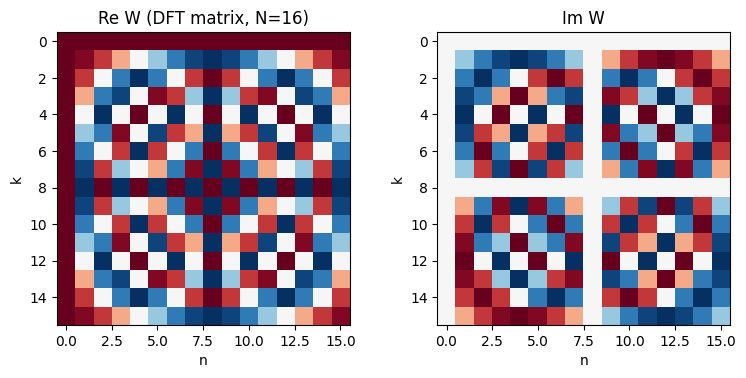

In [2]:
# The naive O(N^2) DFT equals numpy's FFT; the DFT matrix is what FFT computes fast.
rng = np.random.default_rng(0)
x = rng.standard_normal(8)
print("dft == np.fft.fft :", np.allclose(transforms.dft(x), np.fft.fft(x)))

W = transforms.dft_matrix(16)
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].imshow(W.real, cmap="RdBu_r"); ax[0].set_title("Re W (DFT matrix, N=16)")
ax[1].imshow(W.imag, cmap="RdBu_r"); ax[1].set_title("Im W")
for a in ax:
    a.set_xlabel("n"); a.set_ylabel("k")
plt.show()

## 周波数ビンと Nyquist 周波数

標本化周波数 $f_s$、長さ $N$ のとき、ビン $k$ は周波数 $k\,f_s/N$ に対応します。
表現できる最高周波数は **Nyquist 周波数** $f_s/2$。実信号では振幅スペクトルを片側(0〜$f_s/2$)で見ます。

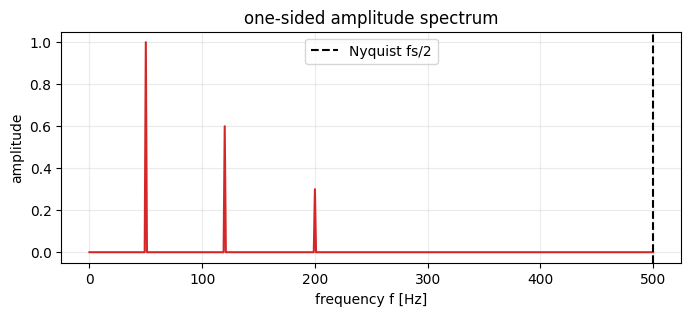

In [3]:
# Real amplitude spectrum of a multitone; nothing exists above Nyquist = fs/2.
fs = 1000.0
t, x = datasets.make_multitone(fs=fs, duration=1.0, freqs=(50, 120, 200), amps=(1.0, .6, .3))
freqs, amp = transforms.amplitude_spectrum(x, fs)
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(freqs, amp, color="#d62728")
ax.axvline(fs / 2, color="black", ls="--", label="Nyquist fs/2")
ax.set_xlabel("frequency f [Hz]"); ax.set_ylabel("amplitude")
ax.set_title("one-sided amplitude spectrum"); ax.legend(); ax.grid(alpha=.25)
plt.show()

## Failure Mode 1 — aliasing(エイリアシング)

標本化が遅すぎる($f_s < 2f$)と、**高周波が低周波になりすまします**。
18 Hz の正弦波を 20 Hz で標本化すると、$|18-20|=2$ Hz の波と区別できません。
標本点が両方の波の上に乗ることを確認します。

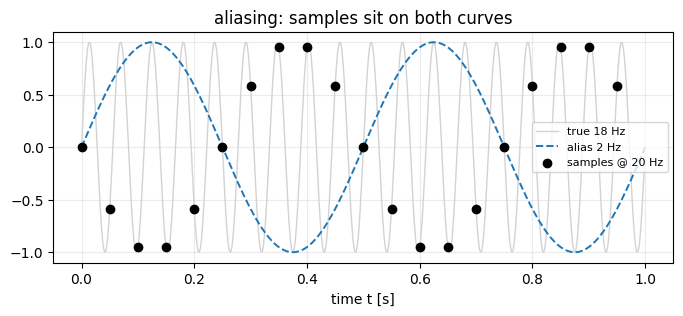

In [4]:
# An 18 Hz tone sampled at 20 Hz looks identical to a 2 Hz tone.
fs = 20.0
ts, _ = signals.time_grid(1.0, fs)
xs = signals.sine(ts, 18.0)

dense = np.linspace(0, 1, 1000)
true_wave = signals.sine(dense, 18.0)
alias_wave = signals.sine(dense, 2.0)        # |18 - 20| = 2 Hz

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(dense, true_wave, color="lightgray", lw=1, label="true 18 Hz")
ax.plot(dense, alias_wave, color="#1f77b4", lw=1.4, ls="--", label="alias 2 Hz")
ax.scatter(ts, xs, color="black", zorder=5, label="samples @ 20 Hz")
ax.set_xlabel("time t [s]"); ax.set_title("aliasing: samples sit on both curves")
ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.show()

## Failure Mode 2 — スペクトル漏れと窓関数

DFT は信号が「丁度ビンに乗る」周期だと仮定します。半端な周波数(例 10.5 Hz、
ビンは 1 Hz 刻み)だと、エネルギーが隣のビンへ **漏れ** ます。
**窓関数**(端を滑らかに 0 へ落とす)を掛けると漏れの裾が減ります
(代わりに山が少し太る、というトレードオフ)。

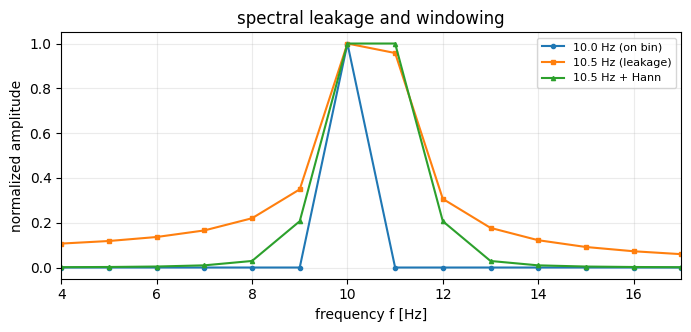

In [5]:
# Leakage: a 10.5 Hz tone (off-bin) smears; a Hann window tames the skirts.
fs = 128.0
t, _ = signals.time_grid(1.0, fs)             # N=128, 1 Hz bins
on_bin = signals.sine(t, 10.0)
off_bin = signals.sine(t, 10.5)
win = np.hanning(len(t))

def norm_spec(sig):
    f, a = transforms.amplitude_spectrum(sig, fs)
    return f, a / a.max()                      # normalise to peak for shape comparison

f0, s_on = norm_spec(on_bin)
_, s_off = norm_spec(off_bin)
_, s_off_w = norm_spec(off_bin * win)

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(f0, s_on, "o-", ms=3, label="10.0 Hz (on bin)")
ax.plot(f0, s_off, "s-", ms=3, label="10.5 Hz (leakage)")
ax.plot(f0, s_off_w, "^-", ms=3, label="10.5 Hz + Hann")
ax.set_xlim(4, 17); ax.set_xlabel("frequency f [Hz]"); ax.set_ylabel("normalized amplitude")
ax.set_title("spectral leakage and windowing"); ax.legend(fontsize=8); ax.grid(alpha=.25)
plt.show()

### 窓関数の比較

主葉の幅(周波数分解能)と側葉の高さ(漏れ)はトレードオフ。矩形窓は主葉が最も狭いが側葉が最悪。

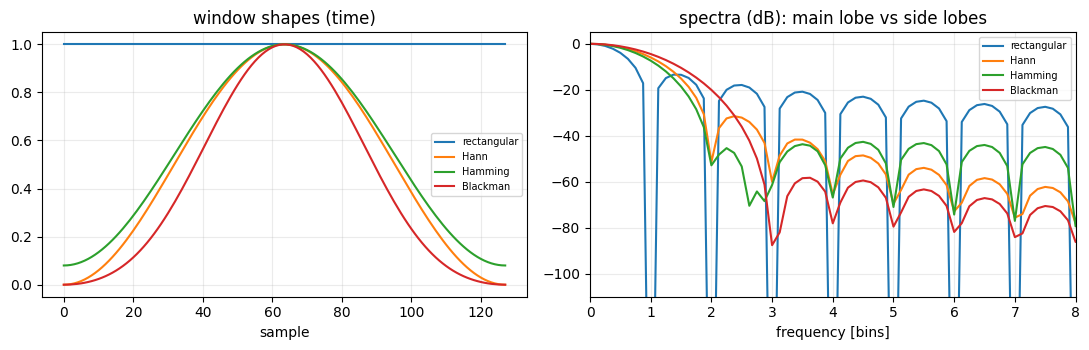

In [6]:
# Window shapes and their side-lobe behaviour (the resolution vs leakage trade-off).
plotting.plot_window_comparison(n=128)
plt.show()

## Invariant / Energy — DFT でも Parseval

DFT でもエネルギーは保存します: $\sum_n |x_n|^2 = \tfrac{1}{N}\sum_k |X_k|^2$(03 章)。
窓を掛けると総エネルギーが変わるため、振幅の絶対値を比較するときは
**窓の利得補正** が要ります(上では形だけ比べるため peak 正規化しました)。

## Application — 実務での DFT

- 録音・センサ・株価など、現実のデータはすべて離散標本 → 解析はすべて DFT/FFT。
- 解析の前に「$f_s$ は十分か(anti-alias フィルタ)」「窓は何を使うか」を必ず考える。
- 周波数分解能は $\Delta f=f_s/N$。細かく見たいなら **長く** 測る(ゼロ詰めは見かけだけ)。

## Exercises

1. **ビンの周波数**: $f_s=1000,\ N=250$ のとき各ビンの周波数刻みは何 Hz か。数値で確認せよ。
2. **折り返し**: $f_s=100$ Hz で 70 Hz の波はどの周波数に alias するか(答 30 Hz)。図で示せ。
3. **窓の比較**: Hann と Hamming、Blackman で漏れの裾と主葉幅を比較せよ。
4. **ゼロ詰め**: 信号にゼロを足すと「滑らかに」見えるが分解能は上がらないことを確かめよ。

## Advanced Notes

```{admonition} なぜ FFT は速いのか
:class: note
DFT を偶数番号・奇数番号に分けると、半分サイズの DFT 二つに分解できる
(Cooley–Tukey)。これを再帰すると $O(N\log N)$。$N=10^6$ で $N^2$ と $N\log N$ は
$10^6$ 倍以上違う — リアルタイム信号処理が成立する理由。
```

- **標本化定理(Nyquist–Shannon)**: 帯域 $B$ に限られた信号は $f_s>2B$ で完全復元できる。
- 窓選択は「周波数分解能 vs ダイナミックレンジ(漏れ)」のトレードオフ。
- 実数信号は `rfft` で半分の計算。スペクトルは共役対称 $X_{N-k}=\overline{X_k}$。